In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.core.debugger import set_trace
import random
import math

import sys
sys.path.insert(0,"/home/kim2712/Desktop/research/conformal_tree")


np.random.seed(59)
sns.set_theme(style="ticks", context="poster", font_scale=1.4)

from conformal_tree import ConformalTreeClassification
from demo_util import gen_sin_data, split_conformal

ALPHA_RANGE = np.arange(0.01,0.25,0.01)
M = 50 #20 #400#200#100 #40
MAX_DEPTH = 24


TEST_SIZE= 0.4 #0.2 #0.8#0.2#0.5

N= int(366 *(1-TEST_SIZE))
MAX_LEAVES = round(N/M) #60

def delta_giver(m): 
    return 2/m +  np.exp(-2*m+1) #math.comb(N+1, m) * ((m/(N+1))**m) * (1-(m/(N+1)))**(N+1-m)

DELTA = delta_giver(M) 
print(DELTA)

0.04


In [12]:
1/N, 1/M, 1/ (366 *(TEST_SIZE)), N, 366 *(TEST_SIZE)

(0.0045662100456621, 0.02, 0.006830601092896175, 219, 146.4)

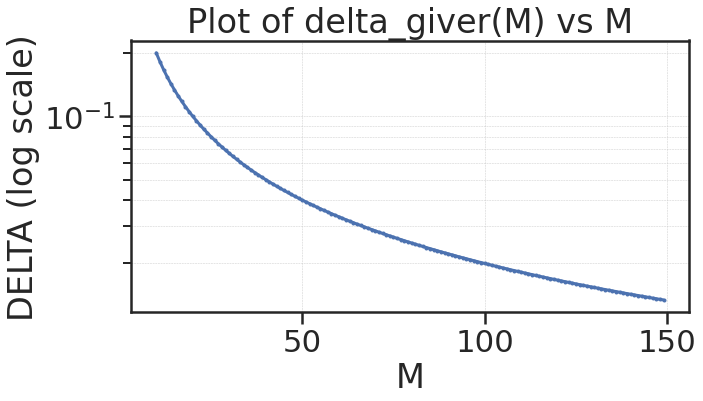

In [13]:
M_values = np.arange(10, 150)
DELTA_values = [delta_giver(M) for M in M_values]

# Plot the function
plt.figure(figsize=(10, 5))
plt.plot(M_values, DELTA_values, marker='o', linestyle='-', markersize=3)
plt.yscale('log')  # Log scale for better visualization
plt.xlabel("M")
plt.ylabel("DELTA (log scale)")
plt.title("Plot of delta_giver(M) vs M")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

# Example data

We demonstrate conformal tree for classification on the dermatology data example

The data is taken from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/33/dermatology)

In [14]:
data_path = '/home/kim2712/Desktop/research/conformal_tree/data/dermatology.data'
df = pd.read_csv(data_path, header=None)

columns = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules',
    'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement',
    'family_history', 'melanin_incontinence', 'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
    'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
    'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges', 'thinning_of_the_suprapapillary_epidermis',
    'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_of_the_granular_layer',
    'vacuolisation_and_damage_of_basal_layer', 'spongiosis', 'saw-tooth_appearance_of_retes',
    'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
    'band-like_infiltrate', 'age', 'class'
]

df.columns = columns

df.replace('?', pd.NA, inplace=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)

df



,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25.0,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36.0,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28.0,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50.0,3


The data contains clinical features, which are observed by a practitioner in a clinical setting, as well as histopathological features, which are studied through blood samples. In this case, we restrict to only clinical features, and try to predict the class of disease from 6 possibilities

In [15]:
feature_columns = [
    'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules',
    'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement',
    'family_history', 'age'
]
clinical_vals = df[feature_columns].values
clinical_labels = df["class"].values
clinical_labels

array([2, 1, 3, 1, 3, 2, 5, 3, 4, 4, 1, 2, 2, 1, 3, 4, 2, 1, 3, 5, 6, 2,
       5, 3, 5, 1, 6, 5, 2, 3, 1, 2, 1, 1, 4, 2, 3, 2, 3, 1, 2, 4, 1, 2,
       5, 3, 4, 6, 2, 3, 3, 4, 1, 1, 5, 1, 2, 3, 4, 2, 6, 1, 5, 1, 2, 3,
       1, 4, 5, 1, 2, 6, 3, 5, 4, 2, 2, 1, 3, 5, 1, 2, 2, 2, 5, 1, 1, 3,
       1, 4, 2, 2, 5, 1, 3, 4, 2, 5, 1, 6, 2, 5, 1, 2, 2, 1, 4, 1, 3, 1,
       1, 3, 5, 3, 3, 5, 2, 3, 4, 1, 2, 5, 6, 1, 1, 2, 6, 3, 5, 4, 1, 1,
       3, 5, 5, 1, 4, 2, 3, 1, 2, 1, 1, 3, 3, 3, 2, 5, 4, 2, 2, 1, 1, 1,
       5, 3, 2, 3, 2, 2, 4, 2, 3, 6, 2, 1, 1, 3, 4, 3, 3, 1, 1, 1, 3, 1,
       1, 2, 3, 3, 1, 1, 1, 1, 6, 2, 2, 2, 2, 1, 3, 3, 3, 1, 1, 2, 3, 2,
       2, 2, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 5, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 6, 6, 1,
       1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 6, 6, 6, 4, 4, 4, 1, 1, 1, 1, 1, 2, 2, 4, 4, 4, 1, 1, 2, 2,
       2, 3, 3, 3, 3, 1, 1, 1, 1, 5, 5, 5, 5, 5, 3,

In this case, the black-box model is using an LLM (GPT-4) to classify the disease based on clinical features. For this demonstration, we provide the response data for each observation in the dermatology dataset. For each sample, GPT assigned probabilities to the six classes. This data is stored as dictionaries in `data/dermdata.json`.

In [16]:
import json
with open("/home/kim2712/Desktop/research/conformal_tree/data/dermdata.json", "r") as f:
    output_data_ = json.load(f)
    #output_data = json.load(f)
#print(output_data_[0])
#output_data[0]

labs_strs = {
    "psoriasis":1,
    "seboreic dermatitis":2,
    "lichen planus":3,
    "pityriasis rosea":4,
    "cronic dermatitis":5,
    "pityriasis rubra pilaris":6
}
output_data= []
random.seed(42)
for prd in output_data_:
    perturbed = {labs_strs[key]:value+random.uniform(0.0001, 0.001) for key, value in prd.items()}
    Z = sum(list(perturbed.values()))
    normalized = {key: (value/Z) for key, value in perturbed.items()}
    output_data.append(normalized)
#output_data
#output_data
#prd.items()

Here is an example of what the predictions for the first sample look like

In [17]:
def compute_coverage(true_ans, conf_sets):
    return np.mean([true_ans[i] in s for i,s in enumerate(conf_sets)])

def conformal_set(test_idx, conf_quant):
    probs = output_data[test_idx]
    #set_trace()
    nonconformity_scores = {label: 1 - prob for label, prob in probs.items()}
    filtered_scores = {label: score for label, score in nonconformity_scores.items() if score <= conf_quant}
    #set_trace()
    return list(filtered_scores.keys())

def conformal_for_alpha(alpha, calib_idx, test_idx):
    #set_trace()
    #test_labs = [labs_strs[key] for key in clinical_labels[test_idx]]
    
    conf_scores = []
    for idx in calib_idx: 
        
    #for i,sp in enumerate(np.array(output_data)[calib_idx]):
        
        
        #true_idx = clinical_labels[calib_idx][i]-1
        #true_label = clinical_labels[calib_idx][i]
        true_label = clinical_labels[idx]
        sp = output_data[idx]
        #conf = 1.0 - float(list(sp.values())[true_idx])
        conf = 1.0 - float(sp[true_label])
        #set_trace()
        conf_scores.append(conf)
    conf_scores = np.array(conf_scores)
    #set_trace()
    n = len(calib_idx)
    conf_quant = np.quantile(conf_scores, min(1,np.ceil((1 - alpha)*(n+1))/n))


    test_conformal_sets = []
    for i,tidx in enumerate(test_idx):
        #set_trace()
        test_pt = clinical_vals[tidx]
        
        test_conformal_sets.append(conformal_set(tidx, conf_quant))

    domain = np.array([[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],
                       [-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],[-1.0,4.0],
                       [-1.0,2.0], [0.0,100.0]])

    ctrc = ConformalTreeClassification(domain=domain,
                                       min_samples_leaf=M, 
                                       max_depth=MAX_DEPTH, 
                                       max_leaves=MAX_LEAVES)
    ctrc.calibrate(clinical_vals[calib_idx], conf_scores, alpha=alpha)

    test_tree_sets, return_group_indices = ctrc.test_set(clinical_vals[test_idx], 
                                           y_test_pred=np.array(output_data)[test_idx], 
                                           return_group_idx=True)

    return test_conformal_sets, test_tree_sets, return_group_indices

def coverage_for_alpha(alpha, calib_idx, test_idx):
    test_conformal_sets, test_tree_sets, return_group_indices = conformal_for_alpha(alpha, calib_idx, test_idx)
    test_labs = clinical_labels[test_idx]
    return np.array([compute_coverage(test_labs, test_conformal_sets),
                     compute_coverage(test_labs, test_tree_sets)])#, conf_quant])

def box_wise_coverage_for_alpha(alpha, calib_idx, test_idx):
    test_conformal_sets, test_tree_sets, return_group_indices = conformal_for_alpha(alpha, calib_idx, test_idx)
    bin_names, counts = np.unique(return_group_indices,return_counts=True)
    test_labs = clinical_labels[test_idx]
    CVRGS = {}
    
    for b_idx in bin_names:
        indices = np.where(return_group_indices==b_idx)[0]
        CVRGS.update({b_idx: np.array([compute_coverage(test_labs[indices], #test_conformal_sets[indices]),
                                                        [test_conformal_sets[idx] for idx in indices]),
                      compute_coverage(test_labs[indices], 
                                      #test_tree_sets[indices]
                                      [test_tree_sets[idx] for idx in indices]
                                     )])})
    print(f"The test set size for each group is: {counts}")
    return CVRGS



def class_wise_coverage_for_alpha(alpha, calib_idx, test_idx):
    test_conformal_sets, test_tree_sets, return_group_indices = conformal_for_alpha(alpha, calib_idx, test_idx)
    test_labs = clinical_labels[test_idx]
    
    CVRGS = {}
    
    for label in range(1,7):
        indices = np.where(test_labs==label)[0]
        #set_trace()
        CVRGS.update({label: np.array([compute_coverage(test_labs[indices], #test_conformal_sets[indices]),
                                                        [test_conformal_sets[idx] for idx in indices]),
                     compute_coverage(test_labs[indices], 
                                      #test_tree_sets[indices]
                                      [test_tree_sets[idx] for idx in indices]
                                     )])})
    return CVRGS


In [18]:
def emp_plot(ax, coverages, n_test, calib_idx, test_idx, alpha_range, legend=True,title ="Empirical Test Coverage" ):# = np.arange(0.01,1.00,0.01)): 
             
    
    sns.set(style="ticks", context="poster", font_scale=1.1)
    ax.axhline(1, color="grey",alpha = 0.1,  ls="--")
    #set_trace()
    
    ax.plot(1-alpha_range, coverages[:,1], color="red", ls="-.", label="Conformal Tree")
    ax.plot(1-alpha_range, coverages[:,0], color="blue", ls=":", label="Split Conformal")
    # ax.plot(1-alpha_range, coverages[:,2], color="purple", label="Threshold")
    ax.plot(1-alpha_range, 1-alpha_range, color="grey", alpha=0.3, label="Identity")

    #ax.set_xlim(0.75,1.0)
    ax.set_ylim(0.75,1.01)

    #ax.plot(alpha_range, alpha_range + 1/(40+1), color="green", alpha=0.3, ls="--", label="Theoretical bound")
    ax.plot(1-alpha_range, 1-alpha_range + DELTA + 1/(1+M), color="green", alpha=0.3, ls="--")#, label="Theoretical bound")
    ax.plot(1-alpha_range, 1-alpha_range - DELTA, color="green", alpha=0.3, ls="--", label="Theoretical Bound (ours)")
    ax.plot(1-alpha_range, 1-alpha_range + 1/(1+N), color="purple", alpha=0.3, ls="--", label="Theoretical Bound (split)")
 

    ax.set_xlabel(r"$1-\alpha$")
    ax.set_ylabel("Coverage")
    ax.set_title(title + f"(size:{n_test})")
    if legend:
        ax.legend(edgecolor="black")
    
    

In [19]:
'''
output_data = []
selected_idx = []
for i,y in enumerate(clinical_labels):
    if y  ==6: continue 
    output_data.append(output_data_[i])
    selected_idx.append(i)
print(output_data[0])
'''

'\noutput_data = []\nselected_idx = []\nfor i,y in enumerate(clinical_labels):\n    if y  ==6: continue \n    output_data.append(output_data_[i])\n    selected_idx.append(i)\nprint(output_data[0])\n'

In [20]:
#clinical_labels = clinical_labels[selected_idx]
#clinical_vals = clinical_vals[selected_idx]

In [21]:
len(output_data)

n = len(clinical_vals)
indices = np.arange(0, n)

In [22]:
cov=[]

for seed_idx in range(30):
    random_seed = random.randint(1,100000)
    calib_idx, test_idx = train_test_split(indices, test_size=TEST_SIZE, random_state=random_seed )
    n_test = len(test_idx)
    coverages = np.array([coverage_for_alpha(a, calib_idx, test_idx) for a in ALPHA_RANGE])
    cov.append(coverages)
coverages = np.stack(cov).mean(0)

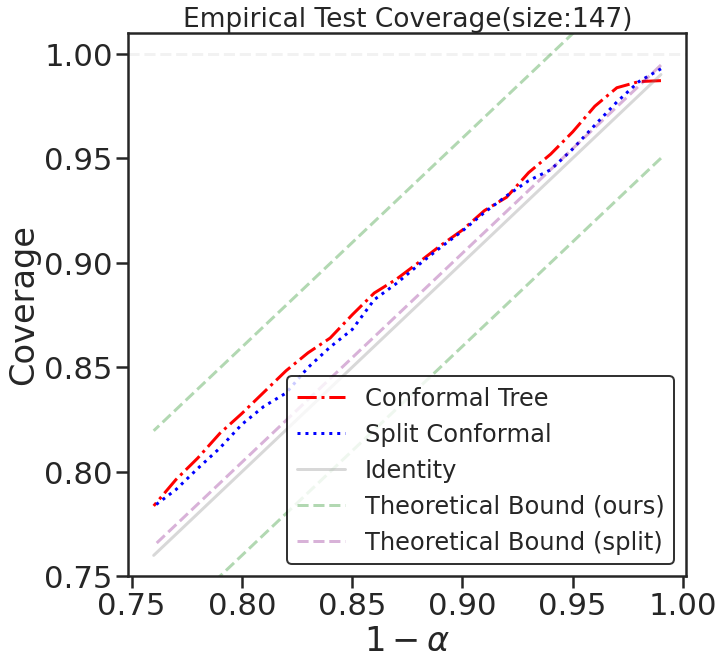

In [23]:
fig, axis= plt.subplots(1,1,figsize=(10,10), sharex=True, sharey=True)
ax = axis#[0]
emp_plot(ax,coverages, n_test,  calib_idx, test_idx, ALPHA_RANGE)
plt.show()

In [24]:
#n = len(clinical_vals)
#indices = np.arange(0, n)
covs=[]
for _ in range(30):
    seed_idx = random.randint(1,100000)
    
    calib_idx, test_idx = train_test_split(indices, test_size=TEST_SIZE, random_state=seed_idx)
    coverages = [class_wise_coverage_for_alpha(a, calib_idx, test_idx) for a in ALPHA_RANGE]

    bin_names, counts = np.unique(clinical_labels[test_idx], return_counts=True)

    COV={}
    for k in range(1,7):
        results = []
        for j, alpha in enumerate(ALPHA_RANGE):
            cov = coverages[j][k]
            results.append(cov)
        COV.update({k:np.array(results)})
    covs.append(COV)

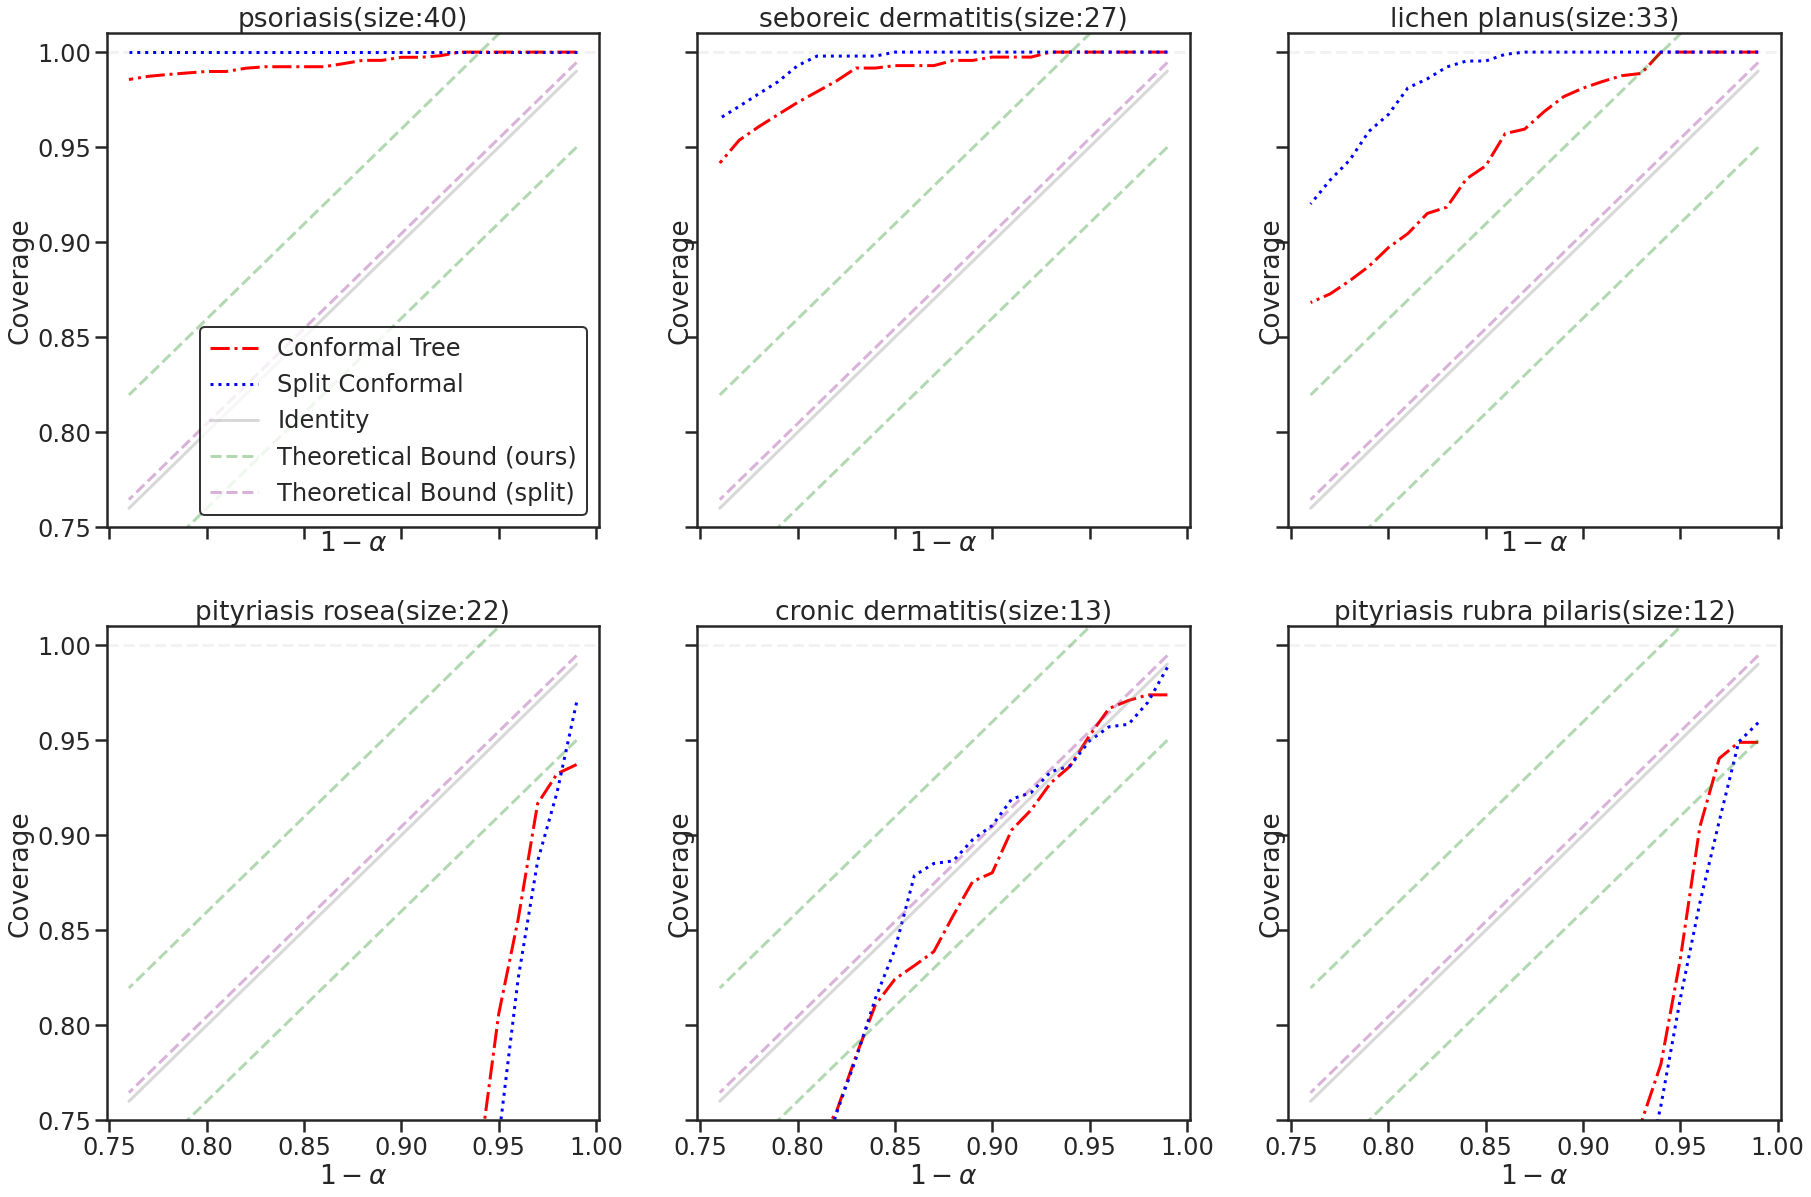

In [25]:
y_order = [
    "psoriasis",
    "seboreic dermatitis",
    "lichen planus",
    "pityriasis rosea",
    "cronic dermatitis",
    "pityriasis rubra pilaris"
]

fig, axis= plt.subplots(2,3,figsize=(30,20), sharex=True, sharey=True)

for j, ax in enumerate(axis.flat):
    k=j+1
    data = np.stack([con[k] for con in covs]).mean(0)
    emp_plot(ax,data,counts[j],calib_idx, test_idx, ALPHA_RANGE, legend = k==1, title=y_order[j])
    
plt.show()

The `test_set` method is used to compute prediction sets for test data. It takes an array of test data of shape $(n,d)$, and a list (or array) of length $n$ of dictionaries with class names as keys and assigned probabilities as labels. 

It returns a list of lists, which contain the class names in each prediction set.